# 05 — Post-processing at node level (run spec v3 §1a, revised 2026-09-29; zero routing)

`v2_run001` as routed (130 nodes, 170 links) with the northern reframe of 2026-09-29: every non-touching link is a corridor on
ONE pressure scale. Writes `<run>/postprocess/` and the record tables; `06_director_outputs` draws from it. The complex-level
work (contraction, `v25_run00x`) is parked in `parked_v3/` (spec §10).

1. **Link kinds + front classes**: `front` (near-contiguous) / `strip`; a front's class from the existing columns -- edge sense D7 as
   routed, route sense = width alone (CUT when the width ratio is below the squeeze threshold; the crossing class -- the maximum cost on the
   direct route -- is reported on every link, never a class driver), no branch decomposition; strips keep their v2 class. `inter_cluster` = the two ends in different components of the front subgraph
   (a reporting filter, not a node definition).
2. **Coverage** per node and per link's dissolved band: existing PAs · IPCAs incremental · the prioritizr core on allocatable land
   (f ≥ 0.70 outside locked PAs = the package's 51,580 km²) · outside all three, with the area-expectation row.
3. **Accounting**: corridor land dissolved; per-class band land dissolved beside per-link sums; front area on its own line; the D25b
   identity (MST strips + MST fronts + augmentation = total per-link band area); branches as links-with-n.
4. **Names**: refugia names in `audit/audit_objects/node_names.csv` (D-W5); labels on the outputs stay NUMBERS until names are chosen.
5. **Act check** (Bow Valley rule), the Nodes and Links tables, T1–T4, the headline, hypotheses H-W1–H-W7, the §9 checklist, GIS.

In [3]:
# ---- Setup: find the project root, import the shared engines ----------------
# This notebook lives in analyses/wolverine_refugia_connectivity/, below the repo root where
# config.py and the corridor engine modules sit. Same bootstrap as analyses/northern_connectivity/.
import sys, pathlib, json
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
          if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import numpy as np
import pandas as pd
import config
import corridors_prep as cp
import corridor_graph as cg
import corridors_core as cc
for _m in (config, cp, cg, cc):
    importlib.reload(_m)

KEY = "wolverine"
CFG = config.CORRIDORS[KEY]
HERE = ROOT / "analyses" / "wolverine_refugia_connectivity"

import matplotlib.pyplot as plt
import corridors_mapstyle as ms
import corridors_director as cd
import director_core as dc
import wolverine_director as wd
for _m in (ms, cd, dc, wd):
    importlib.reload(_m)

import wolverine_postprocess as wp
importlib.reload(wp)
RUN = "v2_run001"
P0 = wp.load(config.RESULTS_DIR / CFG["results_subdir"] / RUN)

v2_run001: results context loaded (170 edges, 44 branches, corridor 52,572 km²)
v2_run001: 130 patches, 170 links = 130 near-contiguous + 40 corridor links (+ 0 adjacency/zero-cost) | cutoff 13.6230 = 4.09 km detour


## 1 · Link kinds, front classes, the inter-cluster flag

In [4]:
links = wp.link_kinds(P0)
display(links.loc[links.kind == "front", ["label_i", "label_j", "link_class", "front_cut", "squeeze_ratio_obs", "crossing_class", "crossing_note", "edge_irreplaceable"]].head(12))

links: 170 = 130 fronts + 40 strips + 0 contacts | fronts: options 72 · narrowing 15 · last affordable 24 · only viable 19 (cut = narrow 34; crossing class on the direct route: {1.0: 115, 10.0: 15}, reported not classed) | front-subgraph components 23; inter-cluster links 37 (strips 37)


,label_i,label_j,link_class,front_cut,squeeze_ratio_obs,crossing_class,crossing_note,edge_irreplaceable
edge_id,,,,,,,,
E000_001,Refugium · R01 Nááts’Ihch’Oh National Park Res...,Refugium · R02 Nááts’Ihch’Oh National Park Res...,securing,False,0.966000,1.0,,False
E000_003,Refugium · R01 Nááts’Ihch’Oh National Park Res...,Refugium · R04 Nááts’Ihch’Oh National Park Res...,securing,False,0.585642,1.0,,False
E001_002,Refugium · R02 Nááts’Ihch’Oh National Park Res...,Refugium · R03 Nááts’Ihch’Oh National Park Res...,securing,False,0.714909,1.0,,False
E002_003,Refugium · R03 Nááts’Ihch’Oh National Park Res...,Refugium · R04 Nááts’Ihch’Oh National Park Res...,edge,False,0.988186,1.0,,True
E003_005,Refugium · R04 Nááts’Ihch’Oh National Park Res...,Refugium · R06 Nááts’Ihch’Oh National Park Res...,edge,False,0.954583,1.0,,True
E004_006,Refugium · R05 Nááts’Ihch’Oh National Park Res...,Refugium · R07 Nááts’Ihch’Oh National Park Res...,edge,False,0.916756,1.0,,True
E005_007,Refugium · R06 Nááts’Ihch’Oh National Park Res...,Refugium · R08 Nááts’Ihch’Oh National Park Res...,securing,False,0.893467,1.0,,False
E005_012,Refugium · R06 Nááts’Ihch’Oh National Park Res...,Refugium · R13 Nahanni National Park Reserve O...,securing,False,0.967039,1.0,,False
E006_012,Refugium · R07 Nááts’Ihch’Oh National Park Res...,Refugium · R13 Nahanni National Park Reserve O...,edge,False,0.892171,1.0,,True


## 2 · Coverage (with the expectation row) · 3 · Accounting · 4 · Names → `postprocess/`

In [5]:
cov = wp.coverage_nodes(P0)
display(cov[cov.kind == "expectation"].round(3))
acc = wp.accounting_nodes(P0)
nd, cn = wp.rename(P0, audit_names_path=HERE / "audit" / "audit_objects" / "node_names.csv", write_audit=True)
P0.nodes["display_name"] = P0.nodes["node_id"].map(nd.set_index("node_id")["display_name"])
lk, ndp = wp.write_node_product(P0)

prioritizr core (balanced scenario, guarded tier on allocatable land, f >= 0.7 outside locked PAs): 51,580 km² at 1 km -> 51,575 km² on the routable 300 m grid
expectation over the routable frame: PAs 13.0% · +IPCAs 11.0% · core 3.3% · outside all three 73.0%
nodes (area-weighted): PAs 35.4% · +IPCAs 8.1% · core 7.5% · outside 49.7%
strip bands (area-weighted): PAs 19.8% · +IPCAs 9.1% · core 4.4% · outside 66.8% | strips crossing land outside PAs + IPCAs: 38 of 40


,kind,id,label,area_km2,pa,ipca_incremental,core,core_incremental,outside_all,mean_ghm90max
0,expectation,0,EXPECTATION: the whole routable Y2Y frame,1551666.6,0.13,0.11,0.033,0.03,0.73,0.094


accounting: corridor land (all bands, dissolved) 52,572 km² | strips dissolved 37,020 (per-link 39,970; outside PAs+IPCAs 25,781, +core 24,456) | fronts dissolved 16,010 (per-link 16,577) | D25b: 18,533 + 12,558 + 25,456 = 56,547 (reconciles) | branches {1: 36, 2: 4} -> 44 vs branches.csv 44
audit node_names.csv: display_name filled for 130 patches (the run-dir copy stays pinned)
names: 130 patches renamed as refugia; 14 display names shared by several patches (e.g. {'Refugium (Nááts’Ihch’Oh)': np.int64(6), 'Refugium (Spatsizi Plateau)': np.int64(6), 'Refugium (Nahanni)': np.int64(4)}) -- disambiguated by their complex
written -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/postprocess: links_v25.csv (170), nodes_v25.csv (130), coverage.csv, accounting.json


## 5 · The package on the product: the act check (Bow Valley rule), the two tables, T1–T4, the headline, hypotheses, the checklist, GIS

In [6]:
wd.STYLE.update(wd.V25_STYLE)
R = wp.attach_nodes(cc.load_results(config.RESULTS_DIR / CFG["results_subdir"] / RUN))
P = wd.package(R)
bow, straddles = wd.bow_valley_check(P)
display(bow)
note = ""
if straddles:                                                   # the rule (spec §8): move the southern break to the Bow Valley, record it
    wd.STYLE["act_breaks_lat"] = (wd.STYLE["bow_valley_lat"],)
    P = wd.package(R); note = f"southern act break moved to the Bow Valley ({wd.STYLE['bow_valley_lat']} N): the Banff-Yoho links straddled 51 N"
    P.act_note = note; print(note)
(R.run_dir / "postprocess" / "acts.json").write_text(json.dumps(dict(break_moved=bool(straddles), act_breaks_lat=list(wd.STYLE["act_breaks_lat"]),
    note=note, links_near_banff=bow.to_dict("records")), indent=2, default=str))

v2_run001: results context loaded (170 edges, 44 branches, corridor 52,572 km²)
attached node-level product: 130 nodes, 130 fronts + 40 strips on one pressure scale
wolverine package: classes -> only viable 19 · last affordable 28 · narrowing 30 · options 93 | geometric classes first (D25/D24): adjacent 0 (barrier between 0), width not assessable 0 | 130 nodes | 3 examples | H8 closed | already connected: 26 within existing PAs, 23 only with the proposed IPCAs (mode 'overlay')
Bow Valley check: 0 corridor link(s) within 60 km of Banff -> one act, no seam issue


""


102

nodes_table: 130 refugia patches -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/tables/nodes_table.csv
links_table: 170 links (40 strips, 130 fronts) -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/tables/links_table.csv


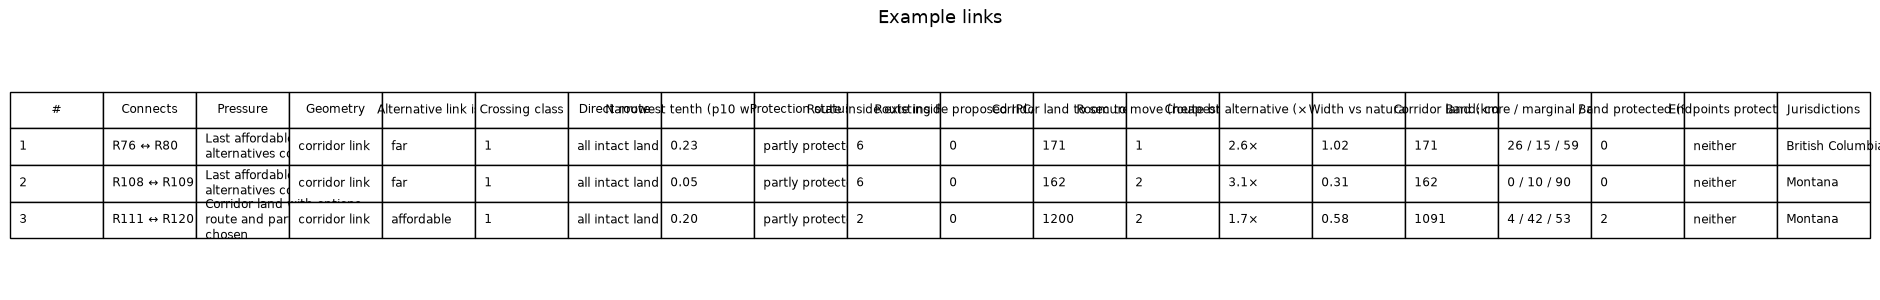

T1_links: 3 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/tables/T1_links.csv
T2_flagged_links: 45 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/tables/T2_flagged_links.csv
T3_all_links: 170 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/tables/T3_all_links.csv
T4_satisfied_links: 49 rows -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/output_data/corridors_wolverine/v2_run001/director_package/tables/T4_satisfied_links.csv
  act  nodes  node_area_km2  node_share_in_pas  node_share_with_ipcas  node_share_in_core  strips_securing  strips_squeezed  strips_edge  strips_both  strips_total  fronts_securing  fronts_squeezed  fronts_edge  fronts_both  fronts_total  narrowing_links
north     92         186138  

,edge_id,Connects,Kind,Inter-cluster,Class,Alternative link is,"Width ratio, median","Width ratio, tenth percentile",Route branches (strips),Crossing class (max cost on the direct route),Direct route,Front cut (narrower than half the barrier-free width),"Band land (km², dissolved per link; links overlap)",Outside PAs and IPCAs (km²),Already connected,In the minimum network,Path (km),Act
136,E107_108,R108 ↔ R109,strip,True,Last affordable link — alternatives cost far more,far,0.31,0.05,2,1,all intact land,<NA>,162,162,no,True,10.8,south
103,E075_079,R76 ↔ R80,strip,True,Last affordable link — alternatives cost far more,far,1.02,0.23,1,1,all intact land,<NA>,171,171,no,True,9.9,north
153,E115_125,R116 ↔ R126,strip,True,Last affordable link — alternatives cost far more,far,0.64,0.32,1,10,the direct route crosses a road or cut (cost 10),<NA>,615,588,no,True,39.6,south
96,E068_073,R69 ↔ R74,strip,True,Last affordable link — alternatives cost far more,far,0.58,0.61,1,1,all intact land,<NA>,76,33,no,True,7.8,north
135,E106_110,R107 ↔ R111,strip,True,Already narrowing — corridor below its natural...,affordable,0.23,0.07,2,10,the direct route crosses a road or cut (cost 10),<NA>,180,180,no,True,16.8,south
149,E111_118,R112 ↔ R119,strip,True,Already narrowing — corridor below its natural...,—,0.29,0.09,1,10,the direct route crosses a road or cut (cost 10),<NA>,537,517,no,False,64.5,south
109,E083_088,R84 ↔ R89,strip,True,Already narrowing — corridor below its natural...,—,0.42,0.11,1,10,the direct route crosses a road or cut (cost 10),<NA>,729,709,no,True,92.1,north
156,E116_122,R117 ↔ R123,strip,True,Already narrowing — corridor below its natural...,—,0.38,0.11,1,10,the direct route crosses a road or cut (cost 10),<NA>,654,527,no,False,58.2,south
105,E077_081,R78 ↔ R82,strip,True,Already narrowing — corridor below its natural...,—,0.48,0.12,1,10,the direct route crosses a road or cut (cost 10),<NA>,1275,1232,no,False,105.6,north
130,E102_105,R103 ↔ R106,strip,False,Already narrowing — corridor below its natural...,—,0.30,0.14,1,1,all intact land,<NA>,188,185,no,False,32.1,south


In [7]:
tN = wd.table_nodes_v25(P); tL = wd.table_links_v25(P)
t1 = wd.table_links(P, "examples"); t2 = wd.table_links(P, "flagged"); t3 = wd.table_links(P, "all"); t4 = wd.table_links(P, "satisfied")
hl = wd.headline_v25(P)
hyp = wd.hypotheses_v25(P)
chk = wd.checklist_v25(P, dict(bow_ok=not straddles or bool(note), bow_note=(note or f"{len(bow)} strip(s) near Banff in one act")))
wd.export_gis(P)
tL.head(20)

## Done — run `06_director_outputs.ipynb`.